### 4.5 Scenario Engine: SVAR shocks meet the Ensemble

[![content: AI-generated](../_static/badges/ai-generated.svg)](ai-acknowledgement) [![content: human-reviewed & edited](../_static/badges/human-reviewed-edited.svg)](ai-acknowledgement)

$$\Delta_h = \text{shock}\times \mathrm{IRF}_h(\text{driver}\to\text{target}),\quad
\text{shock} = \text{input} - \mathrm{SVAR}_{h=1}$$

$$\hat y^{*}_{h,i} = \hat y_{ens,h,i} + \Delta_{h,i}$$

Only the *surprise* over SVAR's own horizon-1 forecast counts, so the expected macro path
is never double-counted; draws are paired index-for-index (Ensemble draw $i$ with SVAR
bootstrap draw $i$), never randomly matched. Because the shock lands at $t{+}1$, CPI
horizon $h$ receives IRF index $h-1$.

This is the forward-looking counterpart to [§4.4](44_svar)'s historical-decomposition walkthrough. It applies the *same* fitted IRF machinery prospectively (hypothetical shock → future path) rather than retrospectively (actual path → attributed shocks). Compare the two: [§4.4](44_svar)'s real 2021Q1 downside surprise in trimmed-mean inflation was mostly a lagged unemployment effect, not a fresh policy or commodity shock, which is exactly the kind of *SVAR-anticipated* move this section's $\text{shock} = \text{input} - \mathrm{SVAR}_{h=1}$ term is built to net out before a hypothetical scenario moves anything.

*Source: `src/models/scenario.py`, served at `POST /forecast/scenario`*

In [ ]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

#### Explained, step by step

- `input` is the number typed into the shock box (e.g. "unemployment ends up at 5.0%"). The model doesn't use that raw number directly. It first subtracts what SVAR *already expected* for that same variable one quarter ahead ($\mathrm{SVAR}_{h=1}$). What's left, `shock`, is only the **surprise**: the part of the scenario SVAR's own baseline forecast didn't already anticipate. This matters because typing in exactly what SVAR expected anyway isn't a "shock" at all. It should move nothing.
- $\mathrm{IRF}_h(\text{driver}\to\text{target})$ is the impulse-response value from [§4.4](44_svar): how many percentage points the target variable moves, $h$ quarters after a one-unit shock to the driver variable. Multiplying the surprise by this per-horizon sensitivity gives $\Delta_h$, the scenario's structural adjustment at horizon $h$.
- $\Delta_h$ is added on top of the Ensemble's own Monte-Carlo forecast draws $\hat y_{ens,h,i}$ for draw $i$ ([§4.3](43_ensemble)'s 1,000 simulated paths, not just one number), giving a shocked version of that same draw, $\hat y^{*}_{h,i}$. The subscript $i$ is preserved deliberately ("paired index-for-index, never randomly matched"), so draw #37's shocked path is still draw #37's *own* baseline path plus the shock, not a randomly re-shuffled combination that would misrepresent the resulting uncertainty band.
- In one sentence: take a hypothesized scenario, strip out the part SVAR already saw coming, convert the leftover surprise into a CPI effect using SVAR's own estimated sensitivity, and lay that effect on top of the Ensemble's existing uncertainty fan rather than replacing it.

**Static example runs.** `POST /forecast/scenario` accepts any shock variable and size, so a fixed book page can only
illustrate a couple of cases. Two canned examples below for the trimmed-mean target (then the same two for headline CPI), forecast origin 2025Q4,
`n_sims=300`: unemployment ends up at 5.0% (a +0.69pp surprise over SVAR's own horizon-1 forecast) or the cash rate
ends up at 5.0% (a +1.40pp surprise). The top row compares the baseline Ensemble with the same forecast once the shock
is added; the bottom row is exactly what the shock adds, draw by draw. The baselines are the mean of the 300 simulated Ensemble paths, so they sit slightly away from the single point forecasts in the forecast table (for 2026Q1, headline is 3.21% here against 3.15% there, and trimmed mean is 3.34% against 3.30%).

Unemployment surprise: shock=+0.69pp, baseline h1=3.34% -> 3.29%, h8=3.21% -> 3.11% | Cash rate surprise: shock=+1.40pp, baseline h1=3.34% -> 3.34%, h8=3.21% -> 3.23%
Unemployment surprise: largest mean effect -0.128pp at 2027Q1; 10-90th percentile spans zero at 0 of 8 horizons
Cash rate surprise: largest mean effect +0.037pp at 2027Q2; 10-90th percentile spans zero at 7 of 8 horizons


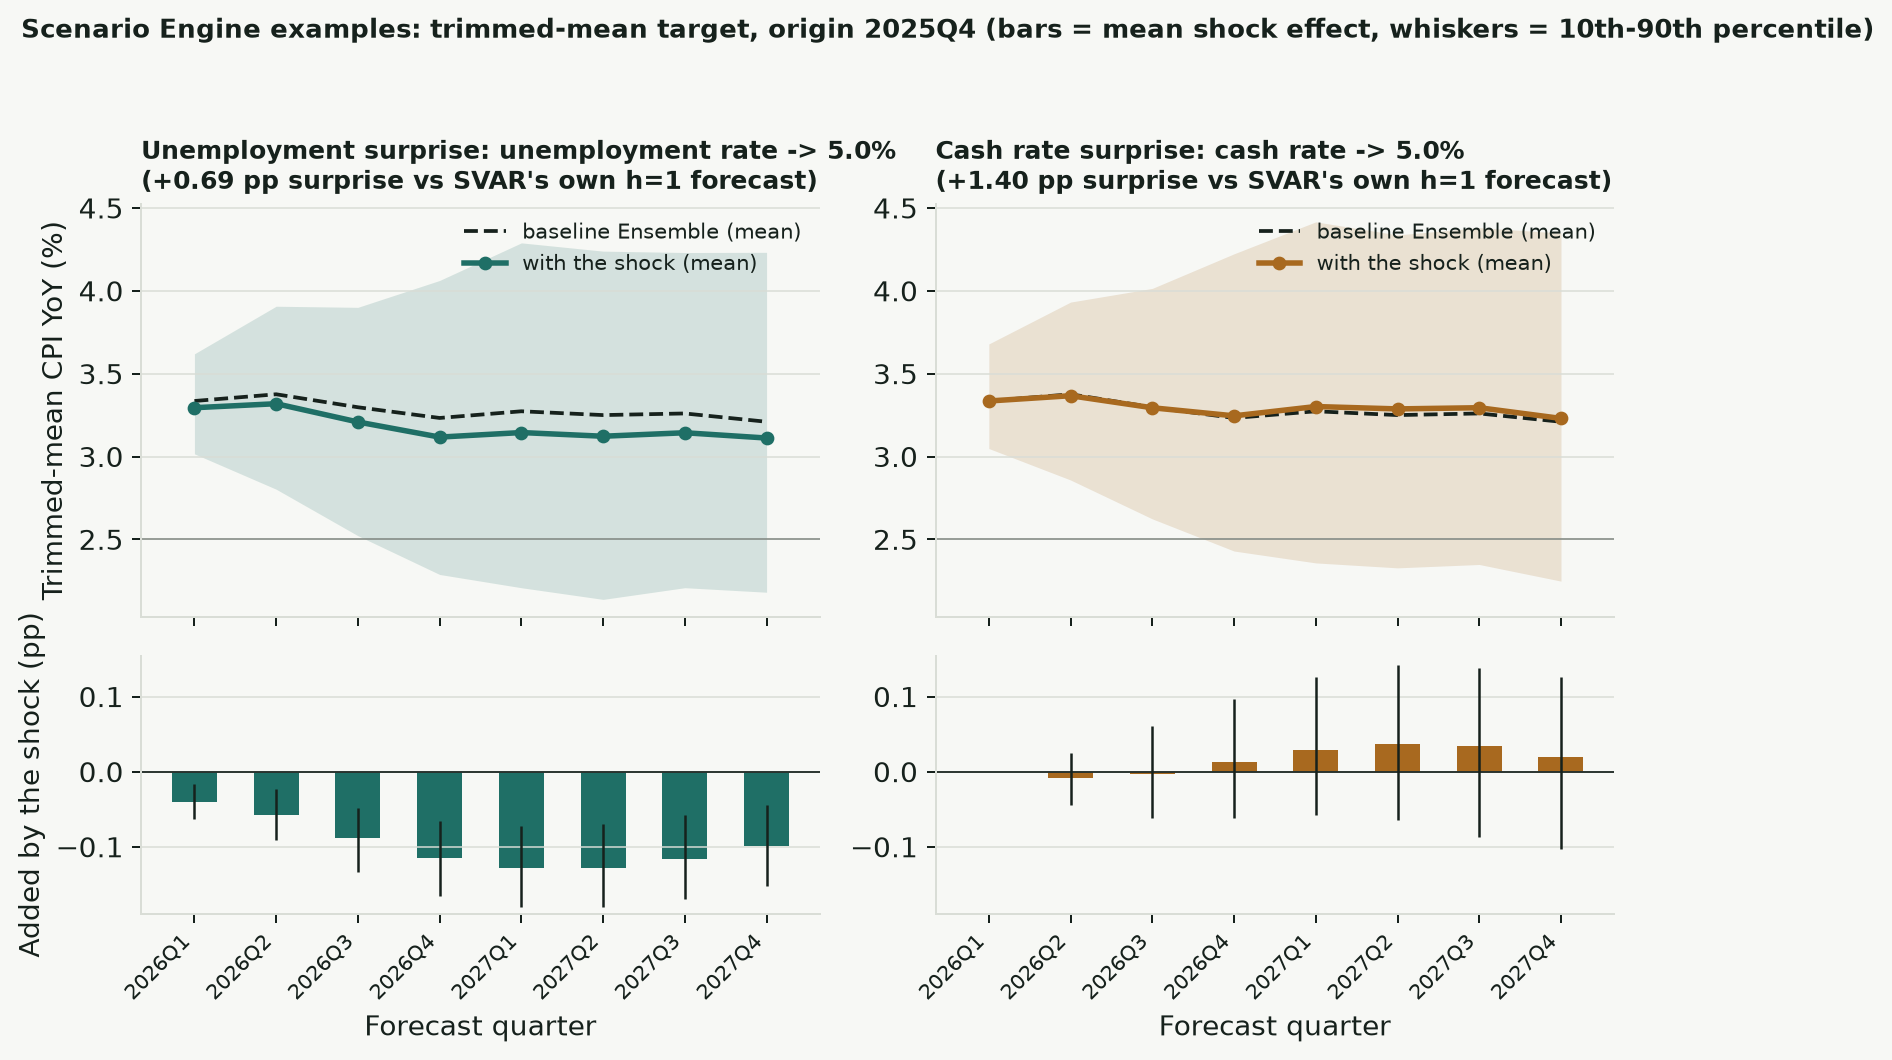

In [2]:
from IPython.display import Image
from src.models import scenario

SCENARIO_CASES = (
    ("Unemployment surprise", "unemployment_rate", 5.0, ACCENT),
    ("Cash rate surprise", "cash_rate", 5.0, HIGHLIGHT),
)
results = [
    scenario.run_scenario(target="trimmed_mean", shock_variable=var, shock_value=val, n_sims=300, seed=42)
    for _, var, val, _ in SCENARIO_CASES
]

fig, axes = plt.subplots(2, 2, figsize=(9.2, 6.0), sharex=True, gridspec_kw={"height_ratios": [1.6, 1]})
for col, ((label, var, val, color), res) in enumerate(zip(SCENARIO_CASES, results)):
    x = np.arange(len(res.horizons))
    baseline = res.baseline_paths.mean(axis=0)          # res.forecast is also a mean over draws
    top, bottom = axes[0, col], axes[1, col]

    top.fill_between(x, res.interval_lower, res.interval_upper, color=color, alpha=0.16, linewidth=0)
    top.plot(x, baseline, color=INK, linewidth=1.5, linestyle="--", label="baseline Ensemble (mean)")
    top.plot(x, res.forecast, color=color, linewidth=2.2, marker="o", markersize=4.5, label="with the shock (mean)")
    top.axhline(2.5, color=INK, linewidth=0.7, alpha=0.4)
    top.set_title(f"{label}: {var.replace('_', ' ')} -> {val:.1f}%\n({res.shock_size:+.2f} pp surprise vs SVAR's own h=1 forecast)",
                  loc="left", fontsize=10, fontweight="bold")
    top.legend(frameon=False, fontsize=8.3, loc="upper right")

    lo, hi = np.percentile(res.shock_contribution, [10, 90], axis=0)
    med = res.shock_contribution.mean(axis=0)
    bottom.axhline(0, color=INK, linewidth=0.7)
    bottom.bar(x, med, width=0.55, color=color)
    bottom.vlines(x, lo, hi, color=INK, linewidth=1.0)
    bottom.set_xticks(x, res.quarters, rotation=45, ha="right", fontsize=8.5)
    bottom.set_xlabel("Forecast quarter")
    if col == 0:
        top.set_ylabel("Trimmed-mean CPI YoY (%)")
        bottom.set_ylabel("Added by the shock (pp)")
    for a in (top, bottom):
        a.grid(axis="x", visible=False)
        a.spines[["top", "right"]].set_visible(False)
top_lo = min(a.get_ylim()[0] for a in axes[0])
top_hi = max(a.get_ylim()[1] for a in axes[0])
for a in axes[0]:
    a.set_ylim(top_lo, top_hi)
bot_lo = min(a.get_ylim()[0] for a in axes[1])
bot_hi = max(a.get_ylim()[1] for a in axes[1])
for a in axes[1]:
    a.set_ylim(bot_lo, bot_hi)
fig.suptitle("Scenario Engine examples: trimmed-mean target, origin 2025Q4 (bars = mean shock effect, whiskers = 10th-90th percentile)",
             fontsize=10.5, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.95))
scenario_path = PROJECT_ROOT / "book/australian_cpi_forecasting/_static/scenario_examples.png"
fig.savefig(scenario_path, dpi=180, bbox_inches="tight")
plt.close(fig)

print(" | ".join(
    f"{label}: shock={res.shock_size:+.2f}pp, baseline h1={res.baseline_paths.mean(axis=0)[0]:.2f}% -> {res.forecast[0]:.2f}%, "
    f"h8={res.baseline_paths.mean(axis=0)[-1]:.2f}% -> {res.forecast[-1]:.2f}%"
    for (label, *_), res in zip(SCENARIO_CASES, results)
))
for (label, *_), res in zip(SCENARIO_CASES, results):
    effect = res.shock_contribution.mean(axis=0)
    lo, hi = np.percentile(res.shock_contribution, [10, 90], axis=0)
    k = int(np.abs(effect).argmax())
    print(f"{label}: largest mean effect {effect[k]:+.3f}pp at {res.quarters[k]}; "
          f"10-90th percentile spans zero at {int(((lo < 0) & (hi > 0)).sum())} of {len(effect)} horizons")
Image(filename=str(scenario_path))

**Reading it.** The unemployment surprise pulls inflation down, in the direction the SVAR's impulse response implies:
by at most about 0.13pp (2027Q1), with the 10th–90th percentile of the effect below zero at every horizon. The cash-rate
surprise is the larger shock but adds at most about 0.04pp (2027Q2), and the 10th–90th percentile of its effect straddles
zero at 7 of 8 horizons. That is consistent with the cash-rate "price puzzle" artifact discussed in [§4.4](44_svar), not
evidence that a rate rise raises inflation. Both effects are small next to the width of the forecast band itself, which is
why every scenario output is illustrative rather than precise. The two surprises are also not comparable per unit: each is
whatever was left after subtracting SVAR's own horizon-1 expectation for that specific variable.

**The same two shocks on headline CPI.** Same forecast origin and settings, but run through the headline system (System A) and the headline Ensemble.

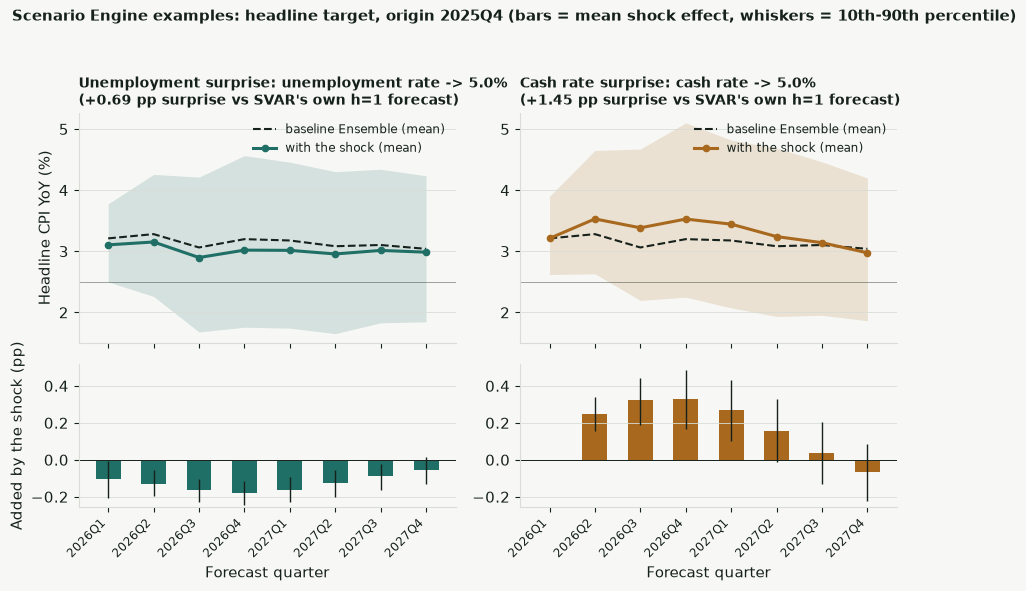

Unemployment surprise: shock=+0.69pp, baseline h1=3.21% -> 3.11%, h8=3.04% -> 2.99% | Cash rate surprise: shock=+1.45pp, baseline h1=3.21% -> 3.21%, h8=3.04% -> 2.98%
Unemployment surprise: largest mean effect -0.180pp at 2026Q4; 10-90th percentile spans zero at 1 of 8 horizons
Cash rate surprise: largest mean effect +0.329pp at 2026Q4; 10-90th percentile spans zero at 3 of 8 horizons


In [2]:
from src.models import scenario

SCENARIO_CASES = (
    ("Unemployment surprise", "unemployment_rate", 5.0, ACCENT),
    ("Cash rate surprise", "cash_rate", 5.0, HIGHLIGHT),
)
results = [
    scenario.run_scenario(target="headline", shock_variable=var, shock_value=val, n_sims=300, seed=42)
    for _, var, val, _ in SCENARIO_CASES
]

fig, axes = plt.subplots(2, 2, figsize=(9.2, 6.0), sharex=True, gridspec_kw={"height_ratios": [1.6, 1]})
for col, ((label, var, val, color), res) in enumerate(zip(SCENARIO_CASES, results)):
    x = np.arange(len(res.horizons))
    baseline = res.baseline_paths.mean(axis=0)          # res.forecast is also a mean over draws
    top, bottom = axes[0, col], axes[1, col]

    top.fill_between(x, res.interval_lower, res.interval_upper, color=color, alpha=0.16, linewidth=0)
    top.plot(x, baseline, color=INK, linewidth=1.5, linestyle="--", label="baseline Ensemble (mean)")
    top.plot(x, res.forecast, color=color, linewidth=2.2, marker="o", markersize=4.5, label="with the shock (mean)")
    top.axhline(2.5, color=INK, linewidth=0.7, alpha=0.4)
    top.set_title(f"{label}: {var.replace('_', ' ')} -> {val:.1f}%\n({res.shock_size:+.2f} pp surprise vs SVAR's own h=1 forecast)",
                  loc="left", fontsize=10, fontweight="bold")
    top.legend(frameon=False, fontsize=8.3, loc="upper right")

    lo, hi = np.percentile(res.shock_contribution, [10, 90], axis=0)
    med = res.shock_contribution.mean(axis=0)
    bottom.axhline(0, color=INK, linewidth=0.7)
    bottom.bar(x, med, width=0.55, color=color)
    bottom.vlines(x, lo, hi, color=INK, linewidth=1.0)
    bottom.set_xticks(x, res.quarters, rotation=45, ha="right", fontsize=8.5)
    bottom.set_xlabel("Forecast quarter")
    if col == 0:
        top.set_ylabel("Headline CPI YoY (%)")
        bottom.set_ylabel("Added by the shock (pp)")
    for a in (top, bottom):
        a.grid(axis="x", visible=False)
        a.spines[["top", "right"]].set_visible(False)
top_lo = min(a.get_ylim()[0] for a in axes[0])
top_hi = max(a.get_ylim()[1] for a in axes[0])
for a in axes[0]:
    a.set_ylim(top_lo, top_hi)
bot_lo = min(a.get_ylim()[0] for a in axes[1])
bot_hi = max(a.get_ylim()[1] for a in axes[1])
for a in axes[1]:
    a.set_ylim(bot_lo, bot_hi)
fig.suptitle("Scenario Engine examples: headline target, origin 2025Q4 (bars = mean shock effect, whiskers = 10th-90th percentile)",
             fontsize=10.5, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

print(" | ".join(
    f"{label}: shock={res.shock_size:+.2f}pp, baseline h1={res.baseline_paths.mean(axis=0)[0]:.2f}% -> {res.forecast[0]:.2f}%, "
    f"h8={res.baseline_paths.mean(axis=0)[-1]:.2f}% -> {res.forecast[-1]:.2f}%"
    for (label, *_), res in zip(SCENARIO_CASES, results)
))
for (label, *_), res in zip(SCENARIO_CASES, results):
    effect = res.shock_contribution.mean(axis=0)
    lo, hi = np.percentile(res.shock_contribution, [10, 90], axis=0)
    k = int(np.abs(effect).argmax())
    print(f"{label}: largest mean effect {effect[k]:+.3f}pp at {res.quarters[k]}; "
          f"10-90th percentile spans zero at {int(((lo < 0) & (hi > 0)).sum())} of {len(effect)} horizons")


**Reading the headline version.** The unemployment surprise pulls headline inflation down by at most about 0.18pp (2026Q4), and at 7 of 8 horizons the 10th to 90th percentile range stays clear of zero. The cash-rate surprise (+1.45pp) again goes the wrong way: it adds up to about 0.33pp (2026Q4), and its range spans zero at 3 of 8 horizons. That's System A's price puzzle from [§4.4](44_svar) showing up in the scenario, not evidence that a rate rise raises inflation. It's also a much larger cash-rate effect than the trimmed-mean version (about 0.33pp against 0.04pp), though still small next to the width of the forecast band.

```{tip}
To run your **own** shock variable and size against the live SVAR + Ensemble pipeline, open **4.5 Scenario Engine** in the [live demo](https://cpi-forecast-demo.streamlit.app/) (a run can take up to a minute), or run `streamlit run app/streamlit_app.py` from the project root with the FastAPI backend reachable at the configured API base URL.
```